In [7]:
import jax

jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro
from numpyro.infer import SVI, Trace_ELBO, init_to_value
from numpyro.infer.autoguide import AutoDelta

# everything from your own package
from cd_dynamax import (
    ContDiscreteNonlinearGaussianSSM,
    adjust_rhs,
    make_optimizer,
    make_key_sequence,
)

from cd_dynamax.src.utils.demo_utils import (
    make_bayesian_nn_drift,
    make_nn_init_dict,
    sample_t_emissions,
    plot_loss_curve,
)

from cd_dynamax.src.utils.plotting_chaos_utils import analyze_chaotic_dynamics

Define True Lorenz 63 Drift Function

In [8]:
sigma = 10.0
rho = 28.0
beta = 8.0 / 3.0


def true_drift(x):
    """Lorenz '63 drift function."""
    x1, x2, x3 = x
    dx1 = sigma * (x2 - x1)
    dx2 = x1 * (rho - x3) - x2
    dx3 = x1 * x2 - beta * x3
    return jnp.array([dx1, dx2, dx3])

In [9]:
# System dimensions
state_dim = 3  # Lorenz '63 has 3 state dimensions
emission_dim = 1  # Here we choose to observe only the first dimension
H = jnp.eye(emission_dim, state_dim)

# Noise parameters
diffusion_coeff_true = 1.0
emission_sd_true = 1.0
initial_state_sd_true = 10.0

# Create the SSM
# Note that default SDE diffeqsolve settings solve using dfx.Heun() with dfx.ConstantStepSize() and dt0=0.01 step size.
import diffrax as dfx

# diffeqsolve_settings = dict(dt0=0.01, solver=dfx.Euler())
diffeqsolve_settings = {}  # use default settings
cdnlgssm = ContDiscreteNonlinearGaussianSSM(
    state_dim=state_dim,
    emission_dim=emission_dim,
    diffeqsolve_settings=diffeqsolve_settings,
)

# Build the true parameters using true_drift and known noise params
known_params = {
    "initial_mean": jnp.zeros(state_dim),
    "initial_cov": (initial_state_sd_true**2) * jnp.eye(state_dim),
    "diffusion_coeff": diffusion_coeff_true * jnp.eye(state_dim),
    "emission_function": lambda x: H @ x,
    "emission_cov": (emission_sd_true**2) * jnp.eye(emission_dim),
}
true_params = cdnlgssm.build_params(drift=true_drift, **known_params)

Simulate data using true parameters

[make_t_emissions] Generated 4000 points from 0.0 to 40.0 with avg step ~0.0100
[make_t_emissions] Smallest time step = 0.010000
Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete non-linear Gaussian SSM path


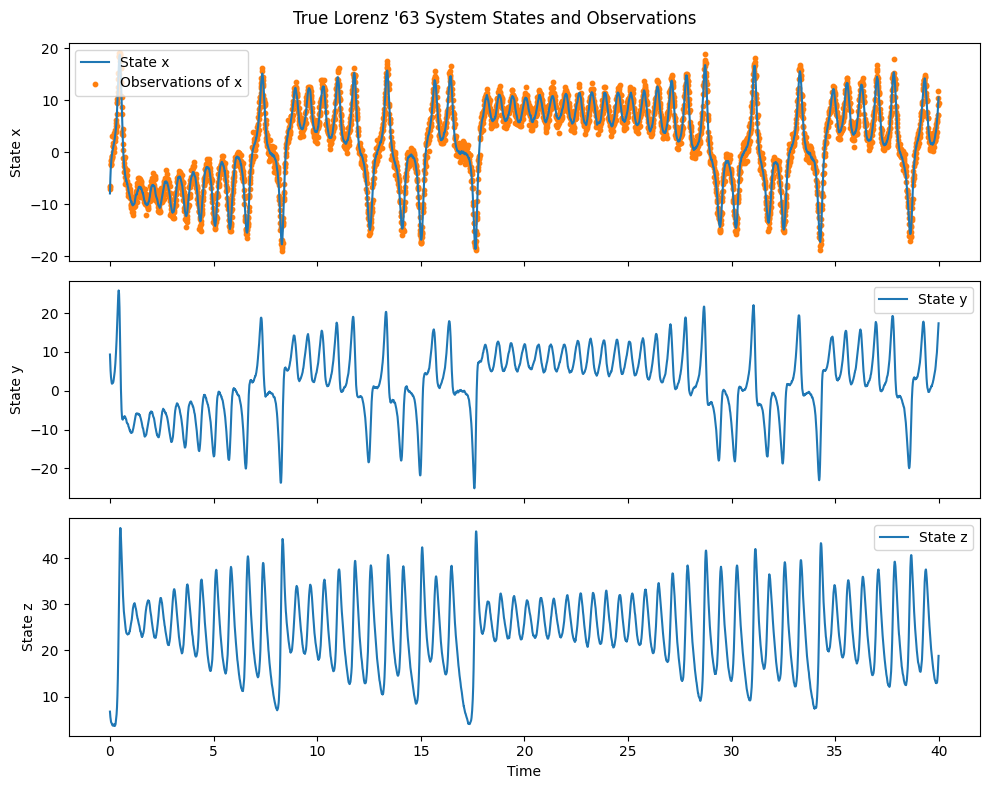

True Log Likelihood: -6029.68329216216


In [10]:
keys = make_key_sequence(1)
t_emissions = sample_t_emissions(
    start=0.0, stop=40.0, dt=0.01, regular=True, key=next(keys)
)

# Simulate data using true parameters (observed at times t_emissions)
# Note that default SDE diffeqsolve settings solve using dfx.Heun() with dfx.ConstantStepSize() and dt0=0.01 step size.
states, emissions = cdnlgssm.sample(
    params=true_params,
    key=next(keys),
    num_timesteps=len(t_emissions),
    t_emissions=t_emissions,
    transition_type="path",
)

# Plot the results in a subplot with 3 rows, with observations overlaid in first emission_dims rows
fig, axs = plt.subplots(state_dim, 1, figsize=(10, 8), sharex=True)
state_labels = ["x", "y", "z"]
for i in range(state_dim):
    axs[i].plot(t_emissions, states[:, i], label=f"State {state_labels[i]}", color="C0")
    if i < emission_dim:
        axs[i].scatter(
            t_emissions,
            emissions[:, i],
            label=f"Observations of {state_labels[i]}",
            color="C1",
            s=10,
        )
    axs[i].legend()
    axs[i].set_ylabel(f"State {state_labels[i]}")
axs[-1].set_xlabel("Time")
plt.suptitle("True Lorenz '63 System States and Observations")
plt.tight_layout()
plt.show()

# Compute likelihood of the observed data under the true parameters
filter_settings = {
    "filter_type": "EnKF",
    "filter_state_order": "first",
    "enkf_N_particles": 25,
}
filtered = cdnlgssm.filter(
    params=true_params, t_emissions=t_emissions, emissions=emissions, **filter_settings
)
true_log_likelihood = filtered.marginal_loglik
print(f"True Log Likelihood: {true_log_likelihood}")

Define a numpyro model with a Neural Network based Drift Function (Uniform prior on weights)

In [11]:
import numpyro.distributions as dist

# Diffeqsolve settings
diffeqsolve_kwargs = dict(
    solver=dfx.Euler(), dt0=1e-2, stepsize_controller=dfx.ConstantStepSize()
)


def _observe_mvn(y_mean, emission_covariance, emissions):
    y = numpyro.sample(
        "y",
        dist.MultivariateNormal(loc=y_mean, covariance_matrix=emission_covariance),
        obs=emissions,
    )  # y_mean shape (T, p) => batch=T, event=p
    numpyro.deterministic("emissions", y)
    return y


# ---------------------------
# Numpyro Meta-model (has 3 modes for computing likelihood)
# MODE = "diffrax"  # "filter" | "eulmar" | "diffrax"
# ---------------------------
def model(
    t_emissions,
    emissions=None,
    nn_hidden_dims=[100],  # single hidden layer with 100 units
    mode="filter",  # "filter" | "eulmar" | "diffrax"
):
    t = jnp.asarray(t_emissions).reshape(-1)
    T = t.shape[0]

    # Build NN-based drift function (uses GeLU activations)
    drift_base = make_bayesian_nn_drift(
        state_dim=state_dim,
        hidden_dims=nn_hidden_dims,  # single hidden layer with 100 units
        prior="uniform",
        prior_scale=10.0,
    )  # note that this drift takes **kwargs to allow passing known drift-params during predictive calls.
    drift = (
        lambda x: adjust_rhs(x, drift_base(x))
    )  # adjust_rhs truncs the drift to avoid extreme values and has it pointing inward at large radius to prevent divergence in early epochs.

    params = cdnlgssm.build_params(drift=drift, **known_params)

    # ============== FILTER mode (marginal likelihood) ==============
    if mode == "filter":
        # Compute (approximate) marginal log likelihood via filtering
        filtered = cdnlgssm.filter(
            params=params,
            emissions=emissions,
            t_emissions=t_emissions,
            **filter_settings,
        )

        if emissions is None:
            states, emissions = cdnlgssm.sample(
                params=params,
                num_timesteps=T,
                key=numpyro.prng_key(),
                t_emissions=t_emissions,
                transition_type="path",
            )
            numpyro.deterministic("states", states)
            numpyro.deterministic("emissions", emissions)

        filtered = cdnlgssm.filter(
            params=params,
            emissions=emissions,
            t_emissions=t_emissions,
            warn=False,
            **filter_settings,
        )
        numpyro.factor("log_likelihood", filtered.marginal_loglik)
        numpyro.deterministic("neg_log_likelihood", -filtered.marginal_loglik)
        return

    # ============== EULMAR mode (NumPyro Euler–Maruyama) ==============
    if mode == "eulmar":
        diffusion_coeff = known_params["diffusion_coeff"]
        diff = (
            jnp.diag(diffusion_coeff) if diffusion_coeff.ndim == 2 else diffusion_coeff
        )  # returns (3,) from a (3,3) input

        def sde_fn(x, ti):
            # drift = _lorenz63_drift(x, sigma, rho, beta)
            # return drift, diff
            return drift(x), diff

        # drift: R^{state_dim} -> R^{state_dim}
        # diffusion: R^{state_dim} -> R^{state_dim, state_dim}
        x_path = numpyro.sample(
            "x_path",
            dist.EulerMaruyama(
                t=t,
                sde_fn=sde_fn,
                init_dist=dist.MultivariateNormal(
                    known_params["initial_mean"], known_params["initial_cov"]
                ),
            ),
        )  # (T, state_dim)

        y_mean = x_path @ H.T
        _observe_mvn(y_mean, known_params["emission_cov"], emissions)
        numpyro.deterministic("states", x_path)
        return

    # ============== DIFFRAX mode (fixed Brownian path) ==============
    if mode == "diffrax":
        if T == 1:
            # No time interval; treat as degenerate "solve"
            x_path = known_params["initial_mean"][None, :]
            y_mean = x_path @ H.T
            _observe_mvn(y_mean, known_params["emission_cov"], emissions)
            numpyro.deterministic("states", x_path)
            return

        if diffeqsolve_kwargs["dt0"] is None:
            diffeqsolve_kwargs["dt0"] = jnp.minimum((t[1:] - t[:-1]).min(), 1.0)

        # Reparameterized Brownian increments (T-1, state_dim)
        dts = t[1:] - t[:-1]
        sqrt_dts = jnp.sqrt(dts)
        z = numpyro.sample(
            "bm_increments", dist.Normal(0.0, 1.0).expand((T - 1, state_dim))
        )
        dW = z * sqrt_dts[:, None]
        W_knots = jnp.concatenate(
            [jnp.zeros((1, state_dim)), jnp.cumsum(dW, axis=0)], axis=0
        )

        bm = dfx.LinearInterpolation(ts=t, ys=W_knots)

        def _drift(ti, x, args):
            return drift(x)

        diffusion_coeff = known_params["diffusion_coeff"]
        diff = (
            jnp.diag(diffusion_coeff) if diffusion_coeff.ndim == 2 else diffusion_coeff
        )  # returns (3,) from a (3,3) input

        def diffusion(ti, x, args):
            return diff

        term = dfx.MultiTerm(
            dfx.ODETerm(_drift),
            dfx.ControlTerm(diffusion, bm),
        )

        x0 = numpyro.sample(
            "x0",
            dist.MultivariateNormal(
                known_params["initial_mean"], known_params["initial_cov"]
            ),
        )
        sol = dfx.diffeqsolve(
            term,
            t0=t[0],
            t1=t[-1],
            y0=x0,
            args=None,
            saveat=dfx.SaveAt(ts=t),
            **diffeqsolve_kwargs,
        )
        x_path = sol.ys  # (T, state_dim)
        y_mean = x_path @ H.T  # (T, emission_dim)

        _observe_mvn(y_mean, known_params["emission_cov"], emissions)
        numpyro.deterministic("states", x_path)
        return

    raise ValueError(f"Unknown mode={mode}")

# Evaluations

### Long-term statistical evaluation
- Generate a very long trajectory from the true model
- Later, we will generate a very long trajectory from the learned model
- Then we will compare their various statistics (histograms, Lyapunov exponents, etc.)

In [12]:
long_t_emissions = jnp.arange(start=0.0, stop=1e4, step=0.01).reshape(-1, 1)


# Long simulation with true parameters for comparison (training data is too short to see true attractor)
states_true_long, emissions_true_long = cdnlgssm.sample(
    params=true_params,
    key=next(keys),
    num_timesteps=len(long_t_emissions),
    t_emissions=long_t_emissions,
    transition_type="path",
)

Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete non-linear Gaussian SSM path


### Short-term filter-then-forecast evaluation
- When you only have partial observations, it is common to take a new sequence of observations and try to continue them into the future
- A classical approach to this is to first perform filtering on the observed data (via an assumed model), then us the final filtered latent state as an initial condition to forecast forward (again, via the assumed model).
- We can investigate how well our model FORECASTS the observed states during the `forecasting` phase
    - We expect a good model to do this well
- We can investigate how well our model reconstructs the latent states during the `filtering` phase
    - A good forecasting model may still do poorly at this without additional knowledge of the latent states and their coordinates, scales, etc.

In [13]:
# Now, generate a new testing trajectory from the true model.
# Do filtering then forecasting (using true and learned models)
# to evaluate short-term forecasting performance
test_t_emissions = sample_t_emissions(
    start=0.0, stop=1000.0, dt=0.01, regular=True, key=next(keys)
)

test_states, test_emissions = cdnlgssm.sample(
    params=true_params,
    key=next(keys),
    num_timesteps=len(test_t_emissions),
    t_emissions=test_t_emissions,
    transition_type="path",
)

ftf_key = next(keys)


def _filter_and_forecast(
    params, key=ftf_key, T0=70.0, T_filter_end=73.0, T_forecast_end=80.0
):
    # Figure out the time points for filtering
    start_idx_filter = jnp.where(test_t_emissions >= T0)[0][0]
    stop_idx_filter = jnp.where(test_t_emissions >= T_filter_end)[0][0]

    # Figure out the time points for forecasting
    start_idx_forecast = jnp.where(test_t_emissions >= T_filter_end)[0][0]
    stop_idx_forecast = jnp.where(test_t_emissions >= T_forecast_end)[0][0]

    assert start_idx_filter < stop_idx_filter, "Filtering time points are invalid."
    assert start_idx_forecast < stop_idx_forecast, (
        "Forecasting time points are invalid."
    )

    filtered, forecasted = cdnlgssm.filter_and_forecast(
        params=params,
        emissions_filter=test_emissions[start_idx_filter:stop_idx_filter],
        t_emissions_filter=test_t_emissions[start_idx_filter:stop_idx_filter],
        t_emissions_forecast=test_t_emissions[start_idx_forecast:stop_idx_forecast],
        key=key,
    )
    return (
        filtered,
        forecasted,
        start_idx_filter,
        stop_idx_filter,
        start_idx_forecast,
        stop_idx_forecast,
    )


def plot_filter_then_forecast(
    filtered,
    forecasted,
    start_idx_filter,
    stop_idx_filter,
    start_idx_forecast,
    stop_idx_forecast,
    t_emissions=test_t_emissions,
    emissions=test_emissions,
    states=test_states,
    title_suffix="",
):
    fig, axs = plt.subplots(state_dim, 1, figsize=(10, 6), sharex=True)
    for i in range(state_dim):
        # Plot true states
        axs[i].plot(
            t_emissions[start_idx_filter:stop_idx_forecast],
            states[start_idx_filter:stop_idx_forecast, i],
            label=f"True state dim {i}",
            color="C3",
        )

        # Plot filtered means
        filter_times = t_emissions[start_idx_filter:stop_idx_filter]
        axs[i].plot(
            filter_times,
            filtered.filtered_means[:, i],
            label=f"Filtered mean dim {i}",
            color="C0",
        )

        # Plot forecasted means
        forecast_times = t_emissions[start_idx_forecast:stop_idx_forecast]
        axs[i].plot(
            forecast_times,
            forecasted.forecasted_state_means[:, i],
            label=f"Forecasted mean dim {i}",
            color="C2",
        )

        # Plot forecasted uncertainty as shaded region
        forecasted_std = jnp.sqrt(
            jnp.diagonal(forecasted.forecasted_state_covariances, axis1=1, axis2=2)[
                :, i
            ]
        )
        axs[i].fill_between(
            forecast_times.squeeze(),
            forecasted.forecasted_state_means[:, i] - 2 * forecasted_std,
            forecasted.forecasted_state_means[:, i] + 2 * forecasted_std,
            color="C2",
            alpha=0.3,
            label="Forecast ±2 stddev",
        )

        # Note where filtering ends and forecasting begins
        axs[i].axvline(
            x=t_emissions[stop_idx_filter - 1],
            color="k",
            linestyle="--",
            label="Forecast start",
        )

        if i < emission_dim:
            # Plot emissions
            axs[i].scatter(
                t_emissions[start_idx_filter:stop_idx_forecast],
                emissions[start_idx_filter:stop_idx_forecast, i],
                label=f"Observations of dim {i}",
                color="C1",
                s=10,
            )

        axs[i].legend(loc="upper right")
        axs[i].set_ylabel(f"State dim {i}")
    axs[-1].set_xlabel("Time")
    plt.suptitle(f"Filtering and Forecasting Results {title_suffix}")
    plt.tight_layout()
    plt.show()

[make_t_emissions] Generated 100000 points from 0.0 to 1000.0 with avg step ~0.0100
[make_t_emissions] Smallest time step = 0.010000
Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete non-linear Gaussian SSM path


### Evaluate TRUE model for filter-then-forecast performance

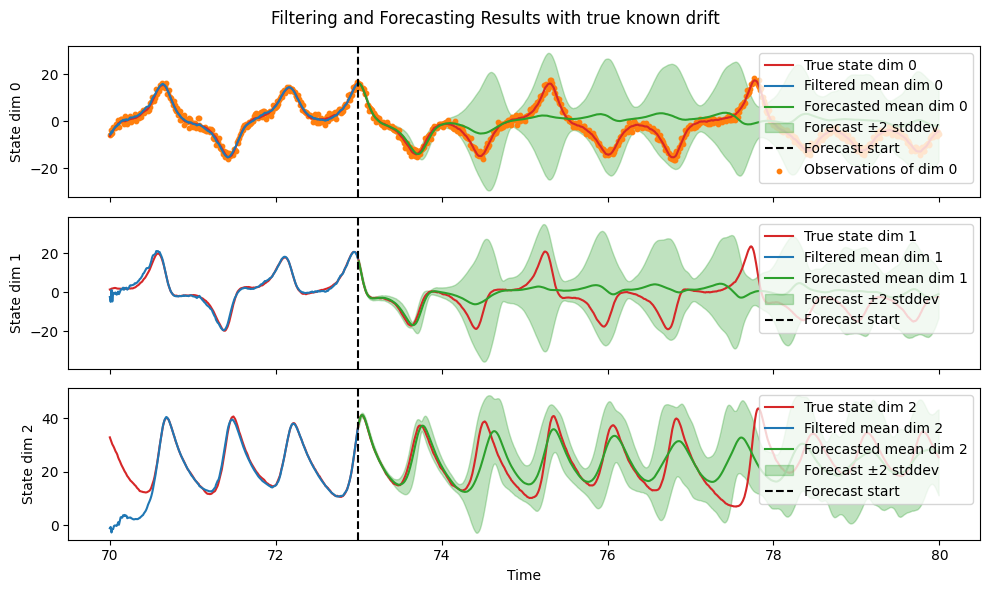

In [14]:
# Filter then forecast using true model
plot_filter_then_forecast(
    *_filter_and_forecast(params=true_params), title_suffix="with true known drift"
)

# Training section
- 3 different training runs corresponding to 3 different likelihood computation modes: "filter", "eulmar", "diffrax"
- Each training run uses SVI to learn the NN weights.

In [15]:
nn_hidden_dims = [100]  # single hidden layer with 100 units
# Initialize at zero
init_params_dict = make_nn_init_dict(next(keys), state_dim, nn_hidden_dims)

svi_results = {}
map_params = {}

### 1. Filter-based training  + short-term evaluation

100%|██████████| 1000/1000 [13:26<00:00,  1.24it/s, init loss: 25777.8543, avg. loss [951-1000]: 8222.3785]

Log Prior under uniform prior: -2105.9997883084557


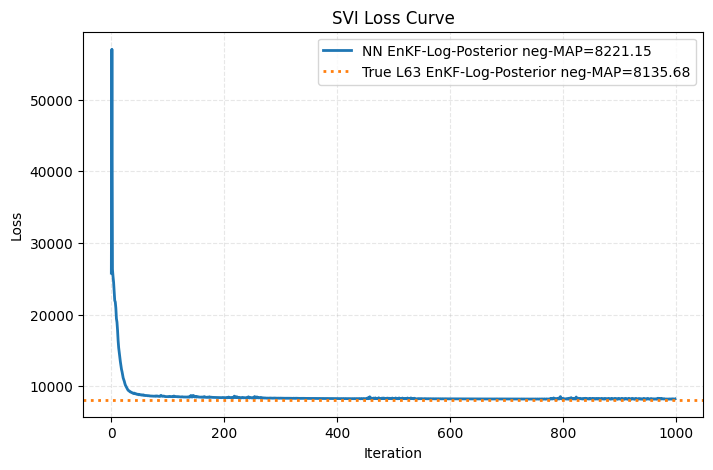

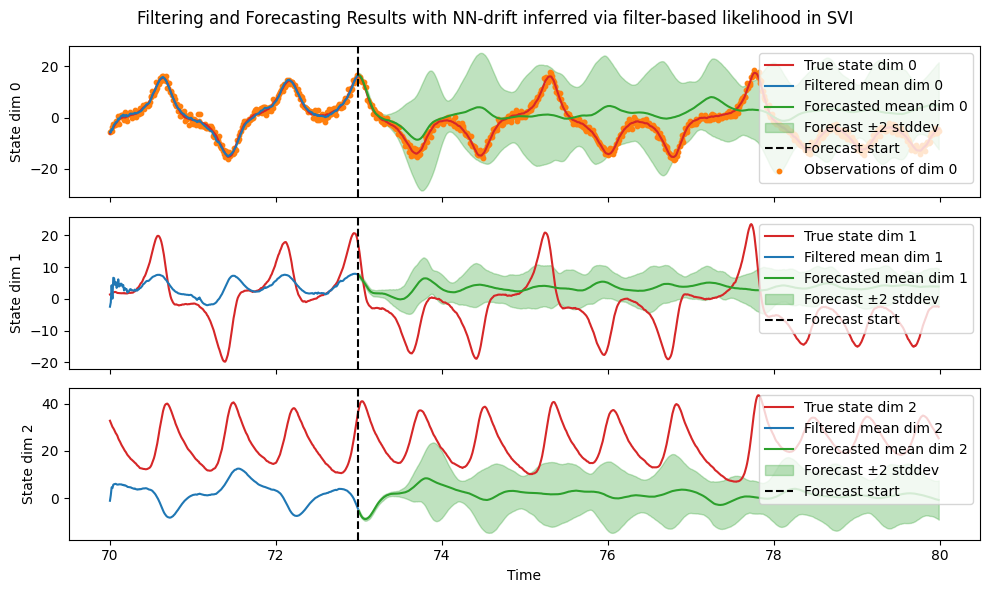

Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete non-linear Gaussian SSM path
Performing long-term statistical comparisons...


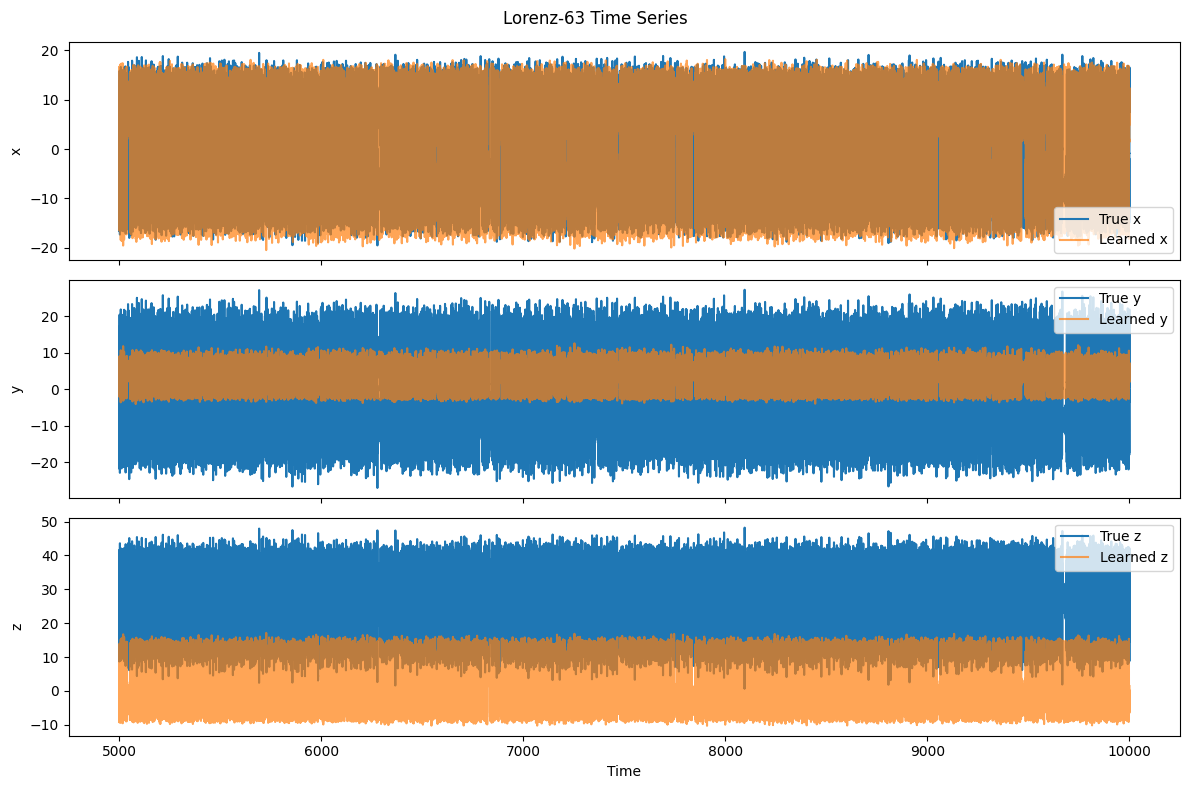

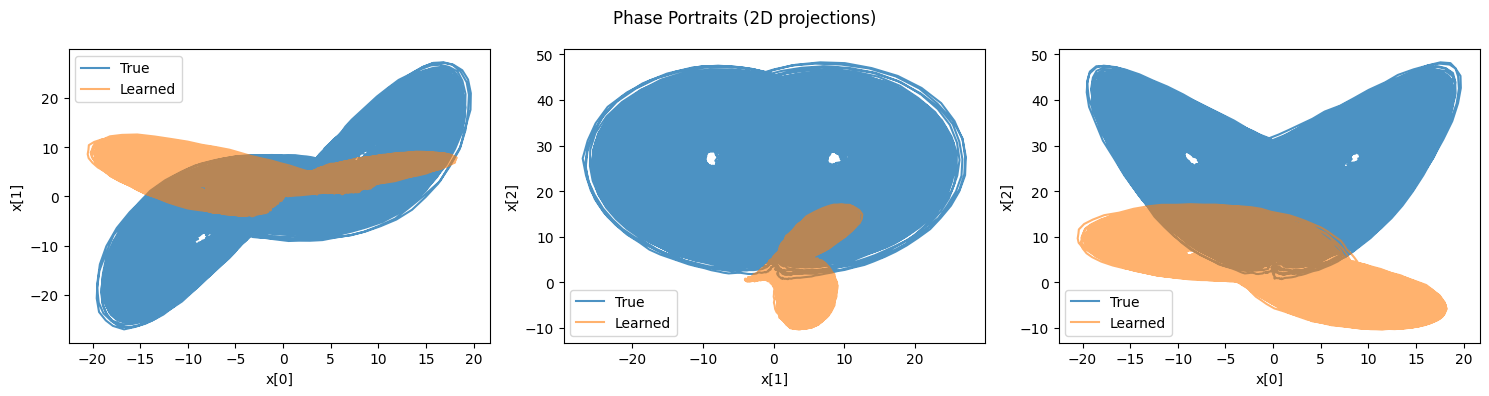

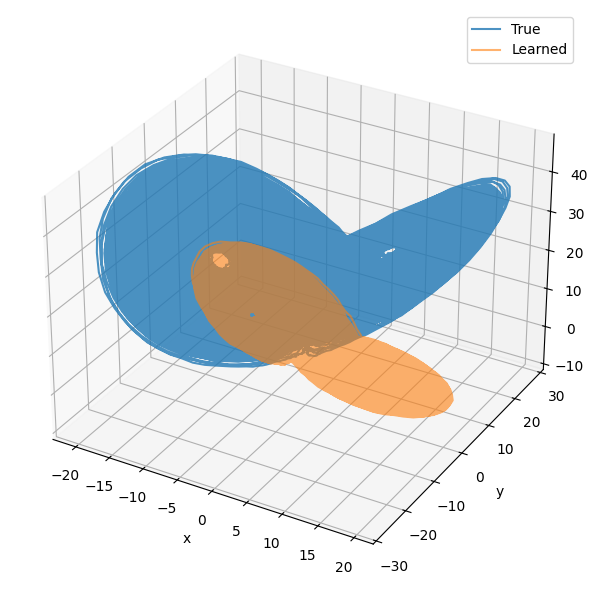

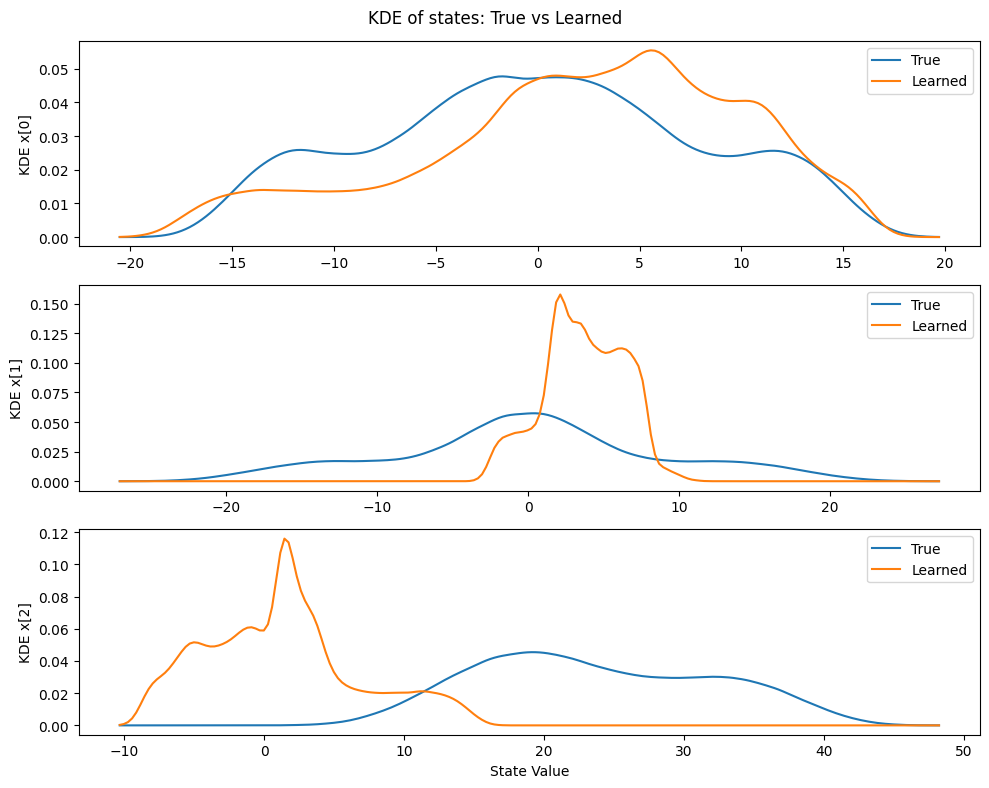

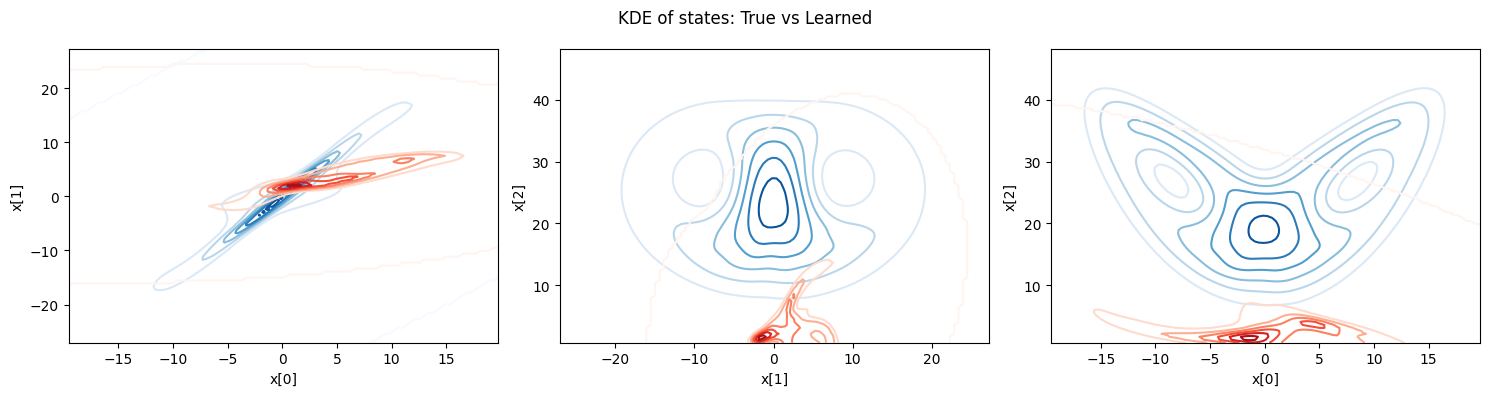

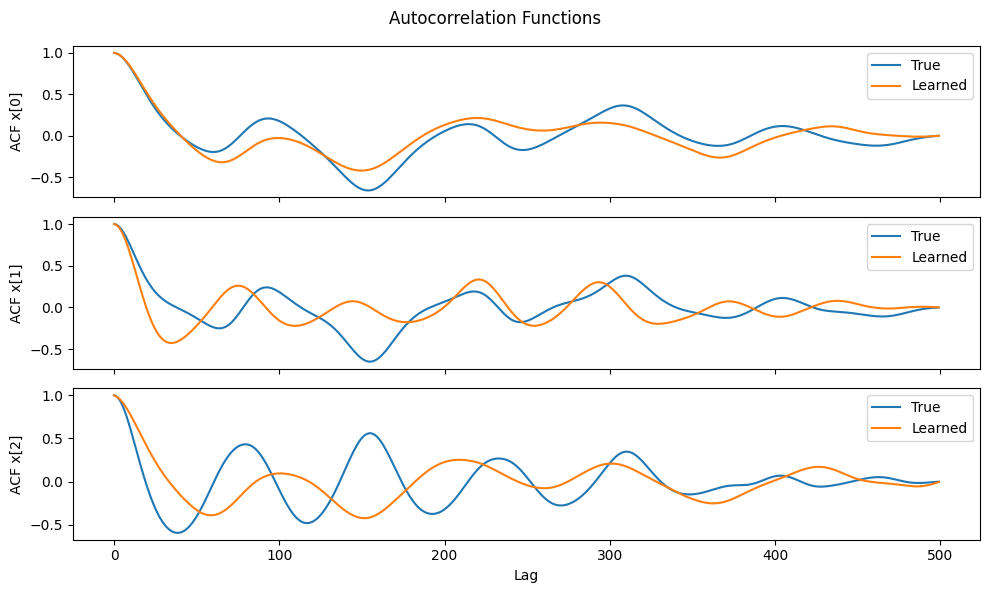

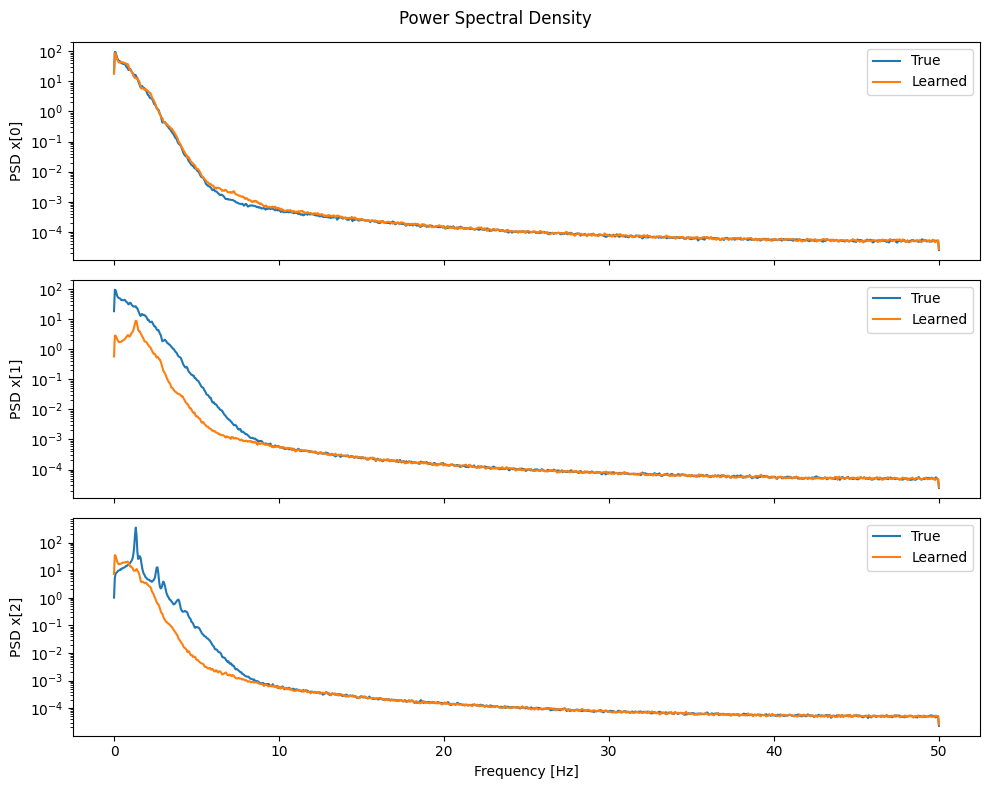

Estimated Largest Lyapunov Exponent:
  True   : 1.028
  Learned: 0.680


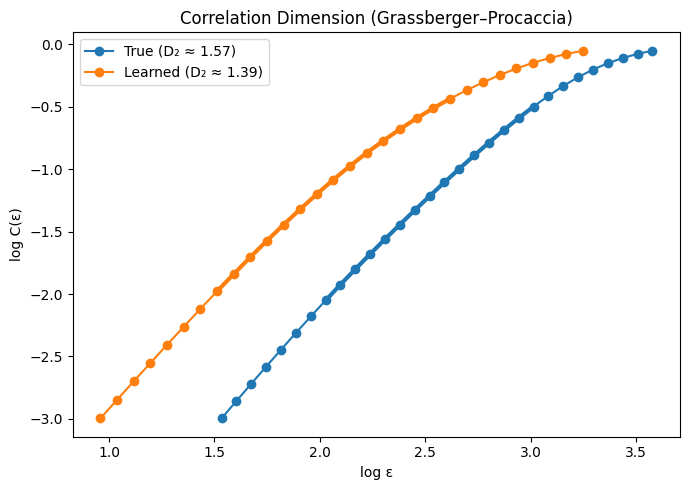

Estimated Correlation Dimension D2:
  True    : 1.570
  Learned : 1.391
Estimated Correlation Dimensions: True D2=1.570, Learned D2=1.391


In [16]:
mode = "filter"  # "filter" | "eulmar" | "diffrax"

# SVI
num_steps = 1000
# Define an optimizer (here it is just Adam with fixed learning rate and gradient clipping)
optimizer = make_optimizer(
    initial_learning_rate=0.005,  #
    # decay_factor=0.5,
    # epochs_per_step=int(num_steps/5),
    # num_epochs=num_steps,
    use_lr_scheduler=0,
    clip_norm=1.0,
)

# Now run SVI for MAP inference!
guide = AutoDelta(model, init_loc_fn=init_to_value(values=init_params_dict))
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())
_svi_results = svi.run(
    next(keys),
    num_steps=num_steps,
    t_emissions=t_emissions,
    emissions=emissions,
    mode=mode,
)
svi_results[mode] = _svi_results

# Plot training curve
# Compute log-prior of uniform prior in 3 => 100 => 3 NN parameter space of [-10, 10]
n_params = (state_dim * nn_hidden_dims[0] + nn_hidden_dims[0]) + (
    nn_hidden_dims[0] * state_dim + state_dim
)
log_prior_uniform = -n_params * jnp.log(
    20.0
)  # since each param has uniform prior over [-10, 10]
print(f"Log Prior under uniform prior: {log_prior_uniform}")
baseline_value = true_log_likelihood + log_prior_uniform
fig = plot_loss_curve(
    svi_results[mode].losses,
    loss_label=f"NN EnKF-Log-Posterior neg-MAP={svi_results[mode].losses[-1]:.2f}",
    baseline_value=-baseline_value,
    baseline_label=f"True L63 EnKF-Log-Posterior neg-MAP={-baseline_value:.2f}",
)
plt.show()

# Extract NN params
map_drift_base = make_bayesian_nn_drift(
    state_dim=state_dim,
    hidden_dims=nn_hidden_dims,  # single hidden layer with 100 units
    prior="uniform",
    prior_scale=10.0,
    **guide.median(svi_results[mode].params),  # pass in learned params
)  # note that this drift takes **kwargs to allow passing known drift-params during predictive calls.
map_drift = (
    lambda x: adjust_rhs(x, map_drift_base(x))
)  # adjust_rhs truncs the drift to avoid extreme values and has it pointing inward at large radius to prevent divergence in early epochs.
map_params[mode] = cdnlgssm.build_params(drift=map_drift, **known_params)

## EVALS:
# Short-term: Filter then forecast using learned Neural SDE map parameters
plot_filter_then_forecast(
    *_filter_and_forecast(params=map_params[mode]),
    title_suffix=f"with NN-drift inferred via {mode}-based likelihood in SVI",
)

# Note that we don't expect the learned 2nd and 3rd state variables to match-up at all to the true ones.
# Long-term: statistical evaluation
states_learned, emissions_learned = cdnlgssm.sample(
    params=map_params[mode],
    key=next(keys),
    num_timesteps=len(long_t_emissions),
    t_emissions=long_t_emissions,
    transition_type="path",
)

print("Performing long-term statistical comparisons...")
analyze_chaotic_dynamics(
    states_true_long,
    states_learned,
    t=long_t_emissions.squeeze(),
    drift_true=true_drift,
    drift_learn=map_drift,
    burnin_frac=0.5,
)

### 2. Euler-Maruyama-based training + short-term evaluation
- Introduce a latent variable at every observation timepoint and infer this `x_path` jointly with the NN weights.

100%|██████████| 100000/100000 [02:57<00:00, 564.42it/s, init loss: 1735979.6509, avg. loss [95001-100000]: -9070.7219]


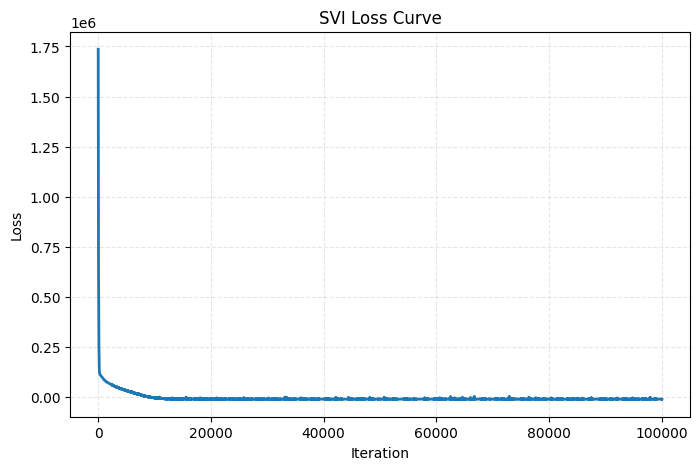

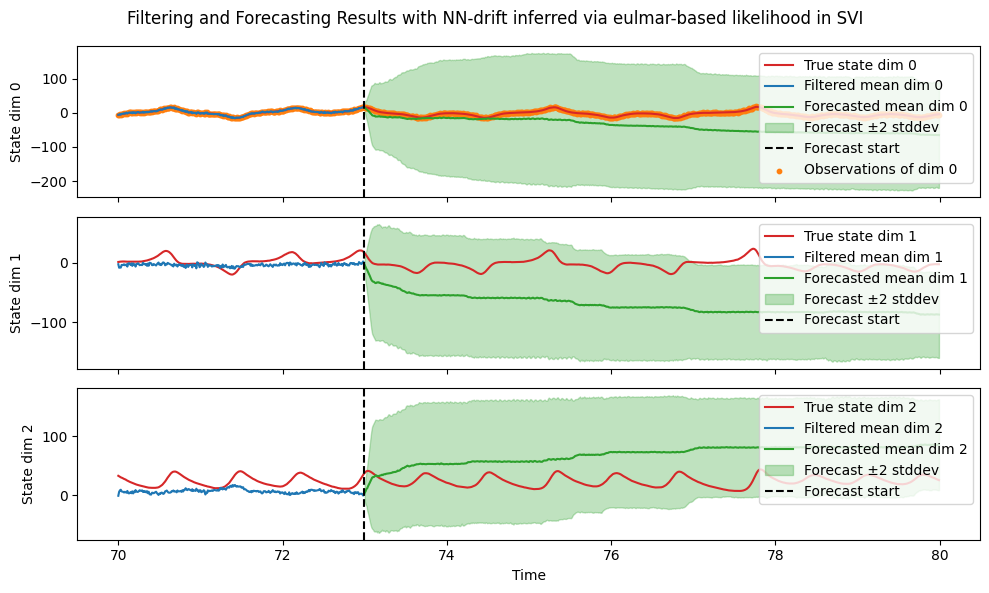

In [17]:
mode = "eulmar"  # "filter" | "eulmar" | "diffrax"

# SVI
num_steps = int(1e5)  # 100000
# Define an optimizer (here it is just Adam with fixed learning rate and gradient clipping)
optimizer = make_optimizer(
    initial_learning_rate=0.005,  #
    # decay_factor=0.1,
    # epochs_per_step=int(num_steps/3),
    # num_epochs=num_steps,
    use_lr_scheduler=0,
    clip_norm=1.0,
)

# Now run SVI for MAP inference!
guide = AutoDelta(model, init_loc_fn=init_to_value(values=init_params_dict))
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())
svi_results[mode] = svi.run(
    next(keys),
    num_steps=num_steps,
    t_emissions=t_emissions,
    emissions=emissions,
    mode=mode,
)

# Plot training curve
fig = plot_loss_curve(
    svi_results[mode].losses,
    loss_label=f"NN {mode}-Log-Posterior neg-MAP={svi_results[mode].losses[-1]:.2f}",
)
plt.show()

# Extract NN params
map_drift_base = make_bayesian_nn_drift(
    state_dim=state_dim,
    hidden_dims=nn_hidden_dims,  # single hidden layer with 100 units
    prior="uniform",
    prior_scale=10.0,
    **guide.median(svi_results[mode].params),  # pass in learned params
)  # note that this drift takes **kwargs to allow passing known drift-params during predictive calls.
map_drift = (
    lambda x: adjust_rhs(x, map_drift_base(x))
)  # adjust_rhs truncs the drift to avoid extreme values and has it pointing inward at large radius to prevent divergence in early epochs.
map_params[mode] = cdnlgssm.build_params(drift=map_drift, **known_params)

## EVALS:
# Short-term: Filter then forecast using learned Neural SDE map parameters
plot_filter_then_forecast(
    *_filter_and_forecast(params=map_params[mode]),
    title_suffix=f"with NN-drift inferred via {mode}-based likelihood in SVI",
)

# Note that we don't expect the learned 2nd and 3rd state variables to match-up at all to the true ones.
# Long-term: statistical evaluation
# states_learned, emissions_learned = cdnlgssm.sample(
#     params=map_params[mode],
#     key=next(keys),
#     num_timesteps=len(long_t_emissions),
#     t_emissions=long_t_emissions,
#     transition_type="path",
# )
# print("Performing long-term statistical comparisons...")
# analyze_chaotic_dynamics(
#     states_true_long,
#     states_learned,
#     t=long_t_emissions.squeeze(),
#     drift_true=true_drift,
#     drift_learn=map_drift,
#     burnin_frac=0.5,
# )

### 3. Diffrax-based training  + short-term evaluation
- Introduce fewer latent variables for `x_path` that are interpolated to form a Virtual Brownian Tree. Path through these latent variables is sampled via diffrax solvers.

100%|██████████| 10000/10000 [13:14<00:00, 12.59it/s, init loss: 18537207.4030, avg. loss [9501-10000]: 17046.6685]


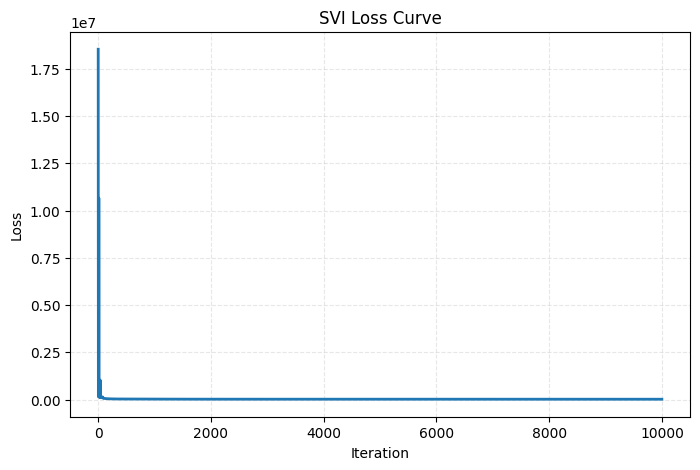

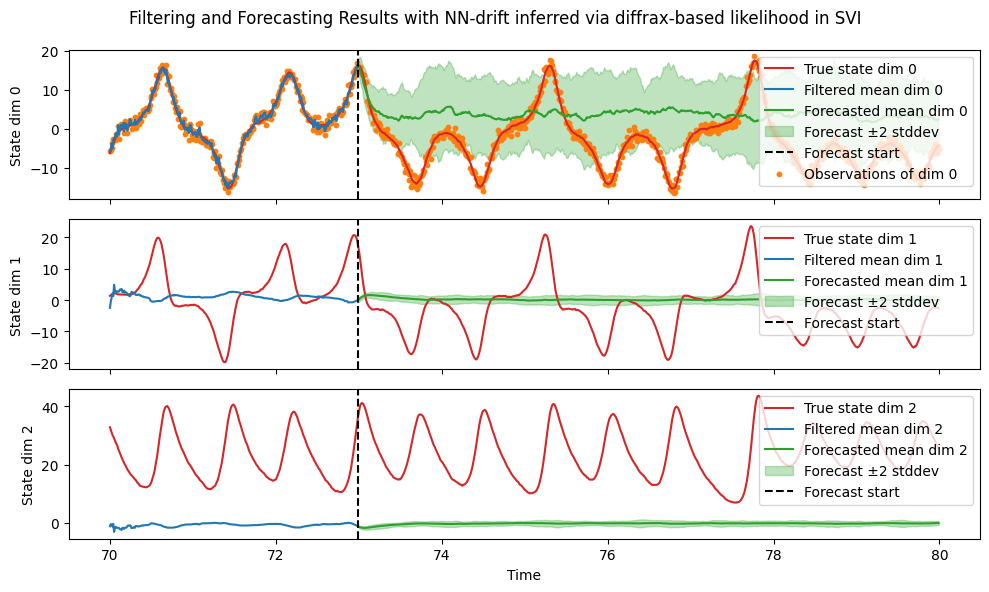

Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete non-linear Gaussian SSM path
Performing long-term statistical comparisons...


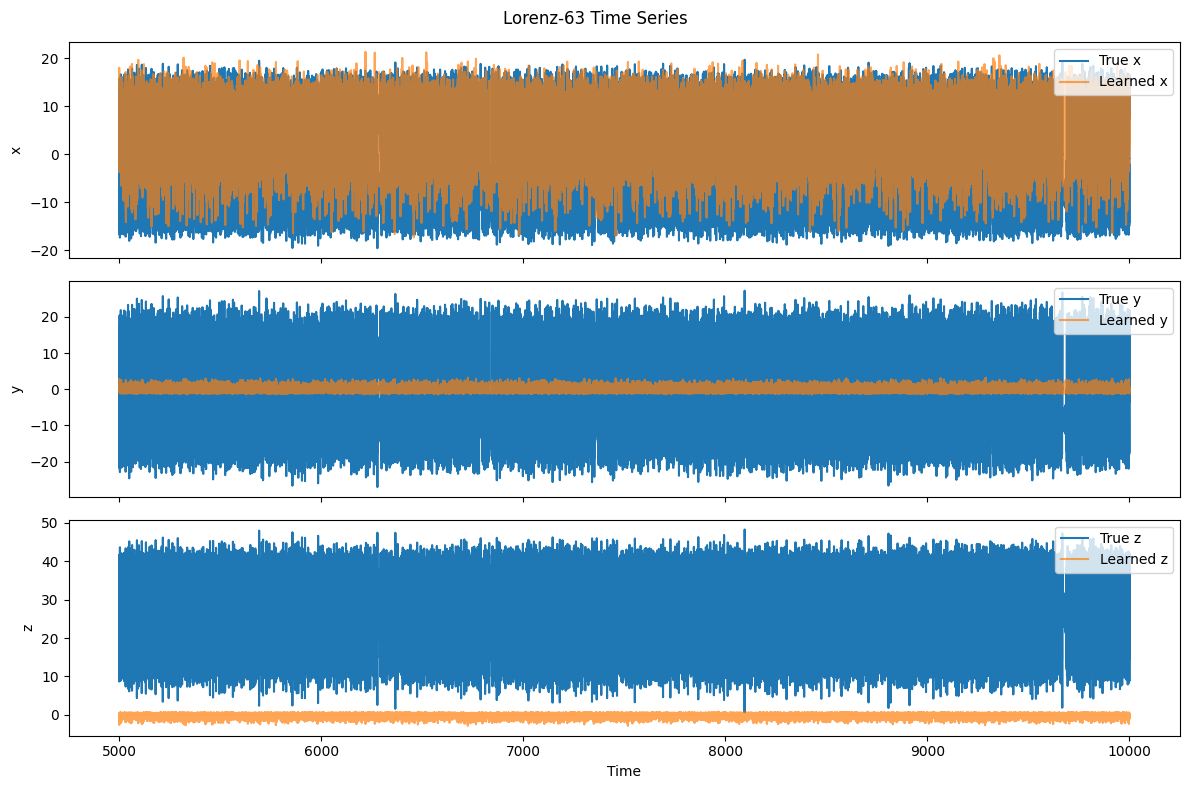

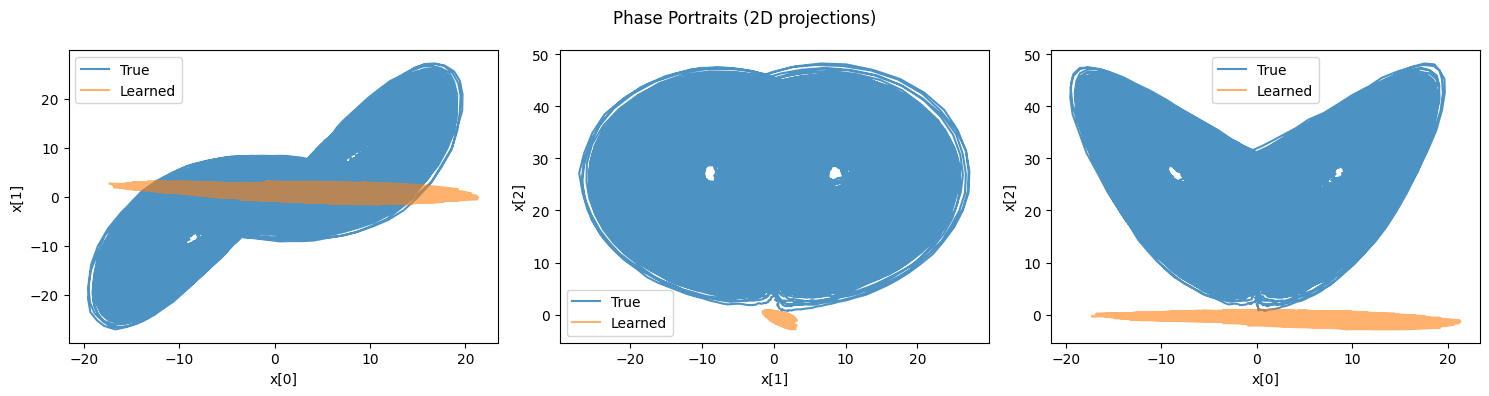

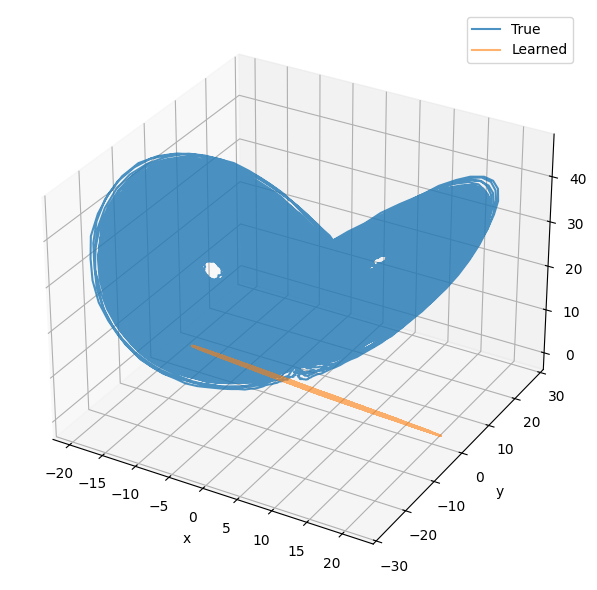

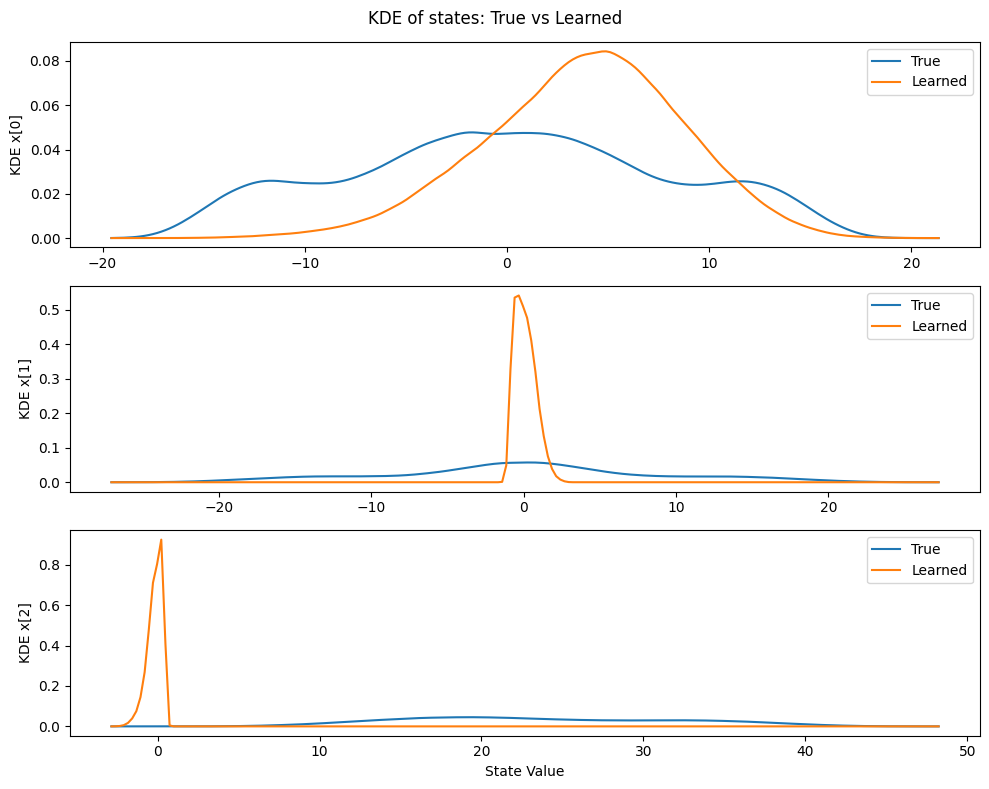

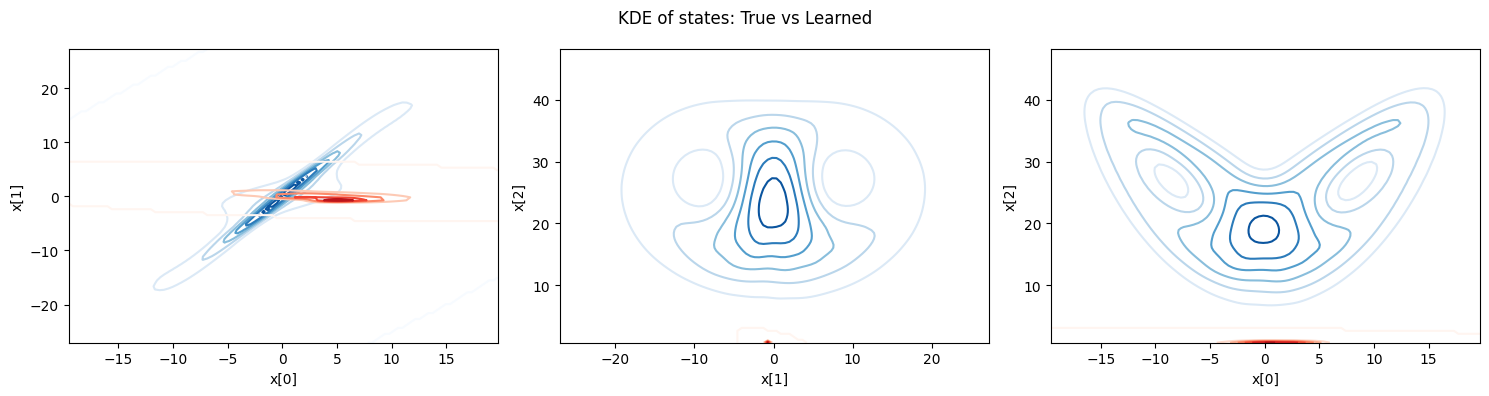

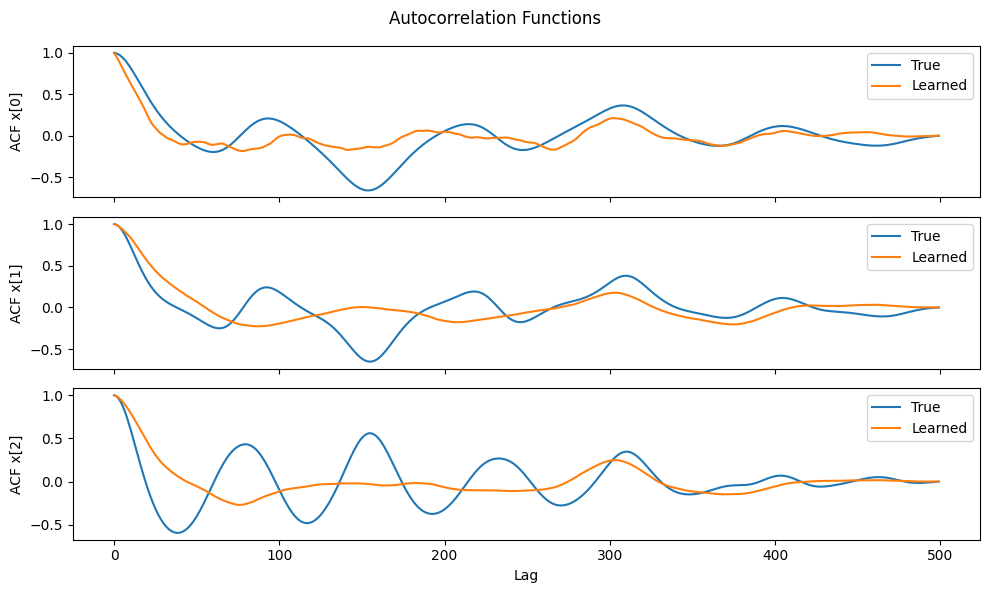

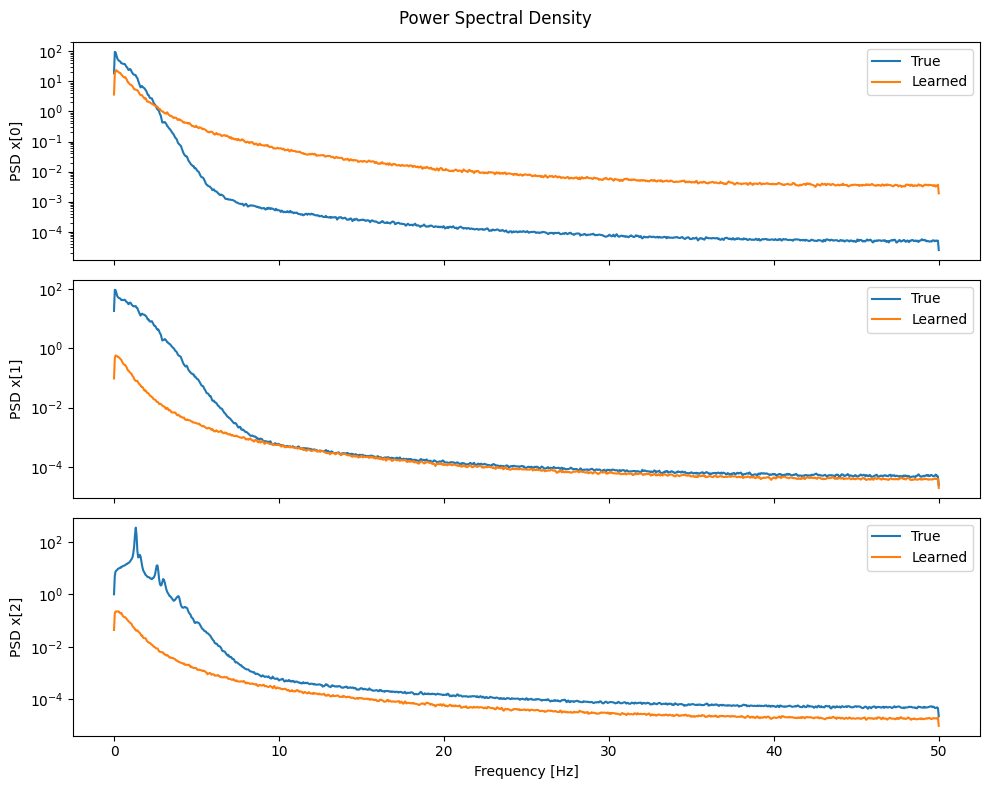

Estimated Largest Lyapunov Exponent:
  True   : 1.029
  Learned: -10.122


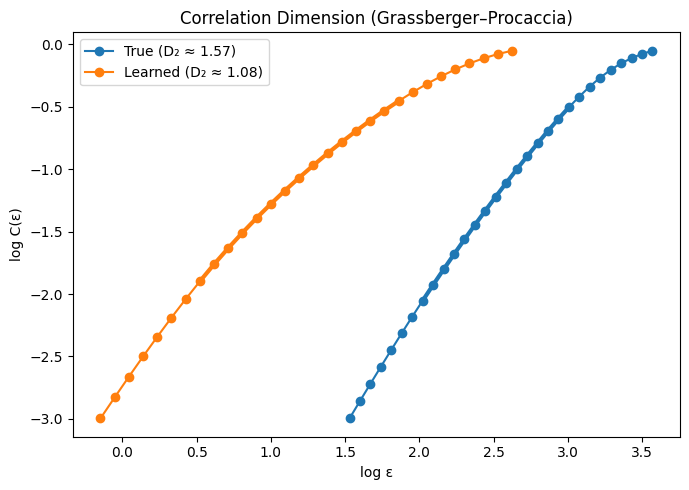

Estimated Correlation Dimension D2:
  True    : 1.570
  Learned : 1.082
Estimated Correlation Dimensions: True D2=1.570, Learned D2=1.082


In [18]:
mode = "diffrax"  # "filter" | "eulmar" | "diffrax"

# SVI
num_steps = 10000
# Define an optimizer (here it is just Adam with fixed learning rate and gradient clipping)
optimizer = make_optimizer(
    initial_learning_rate=0.005,  #
    # decay_factor=0.5,
    # epochs_per_step=int(num_steps/5),
    # num_epochs=num_steps,
    use_lr_scheduler=0,
    clip_norm=1.0,
)

# Now run SVI for MAP inference!
guide = AutoDelta(model, init_loc_fn=init_to_value(values=init_params_dict))
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())
svi_results[mode] = svi.run(
    next(keys),
    num_steps=num_steps,
    t_emissions=t_emissions,
    emissions=emissions,
    mode=mode,
)

# Plot training curve
fig = plot_loss_curve(
    svi_results[mode].losses,
    loss_label=f"NN {mode}-Log-Posterior neg-MAP={svi_results[mode].losses[-1]:.2f}",
)
plt.show()

# Extract NN params
map_drift_base = make_bayesian_nn_drift(
    state_dim=state_dim,
    hidden_dims=nn_hidden_dims,  # single hidden layer with 100 units
    prior="uniform",
    prior_scale=10.0,
    **guide.median(svi_results[mode].params),  # pass in learned params
)  # note that this drift takes **kwargs to allow passing known drift-params during predictive calls.
map_drift = (
    lambda x: adjust_rhs(x, map_drift_base(x))
)  # adjust_rhs truncs the drift to avoid extreme values and has it pointing inward at large radius to prevent divergence in early epochs.
map_params[mode] = cdnlgssm.build_params(drift=map_drift, **known_params)

## EVALS:
# Short-term: Filter then forecast using learned Neural SDE map parameters
plot_filter_then_forecast(
    *_filter_and_forecast(params=map_params[mode]),
    title_suffix=f"with NN-drift inferred via {mode}-based likelihood in SVI",
)

# Note that we don't expect the learned 2nd and 3rd state variables to match-up at all to the true ones.
# Long-term: statistical evaluation
states_learned, emissions_learned = cdnlgssm.sample(
    params=map_params[mode],
    key=next(keys),
    num_timesteps=len(long_t_emissions),
    t_emissions=long_t_emissions,
    transition_type="path",
)
print("Performing long-term statistical comparisons...")
analyze_chaotic_dynamics(
    states_true_long,
    states_learned,
    t=long_t_emissions.squeeze(),
    drift_true=true_drift,
    drift_learn=map_drift,
    burnin_frac=0.5,
)